<a href="https://colab.research.google.com/github/Ubanman0135/COMP2009-Lab10/blob/main/And_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    """Sigmoid activation: sigma(z) = 1 / (1 + exp(-z))."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    """Sigmoid derivative: d_sigma(a) = a * (1 - a)"""
    return a * (1 - a)

In [3]:
def forward_prop(X, W1, b1, W2, b2):
    """
    Compute:
      Z1 = W1∙X + b1
      A1 = sigma(Z1)
      Z2 = W2∙A1 + b2
      A2 = sigma(Z2) <- predicted outputs
    Returns A2 and cache for back-prop.
    """
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

def back_prop(X, Y, cache, W2, m):
    """
    Compute gradients with 1/m normalization:
        dZ2 = (A2 - Y) * sigmoid'(A2)
        dW2 = dZ2∙A1ᵀ * (1/m)
        db2 = sum(dZ2) * (1/m)
        dZ1 = W2ᵀ∙dZ2 * sigmoid'(A1)
        dW1 = dZ1∙Xᵀ * (1/m)
        db1 = sum(dZ1) * (1/m)
    Returns a dict of gradients.
    """
    Z1, A1, Z2, A2 = cache

    # Output-layer gradient
    dZ2 = (A2 - Y) * sigmoid_derivative(A2)   # shape (1, m)
    dW2 = dZ2.dot(A1.T) / m                   # shape (1, 2)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # Hidden-layer gradient
    dA1 = W2.T.dot(dZ2)                     # shape (2, m)
    dZ1 = dA1 * sigmoid_derivative(A1)      # sigmoid'(A1)
    dW1 = dZ1.dot(X.T)/m                  # shape (2, 2)
    db1 = np.sum(dZ1, axis=1, keepdims=True)/m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [4]:
def training_loop(X, Y, W1, b1, W2, b2, lr, m):
    iterations = 10000
    loss_history = []

    for i in range(iterations):
        # 1) Forward pass
        A2, cache = forward_prop(X, W1, b1, W2, b2)

        # 2) Compute normalized MSE loss
        loss = 0.5 * np.sum((A2 - Y)**2)
        loss_history.append(loss)

        # 3) Backward pass
        grads = back_prop(X, Y, cache, W2, m)

        # 4) Parameter update
        W1 -= lr * grads["dW1"]
        b1 -= lr * grads["db1"]
        W2 -= lr * grads["dW2"]
        b2 -= lr * grads["db2"]

        # Print current value of each parameter
        print(f"Iter {i:5d}: {W1}, {b1}, {W2}, {b2}")

    return X, W1, b1, W2, b2, loss_history

In [5]:
def predict(X_new, W1, b1, W2, b2):
    """
    Convert sigmoid outputs to binary predictions using 0.5 threshold.
    """
    A2, _ = forward_prop(X_new, W1, b1, W2, b2)
    return (A2 >= 0.5).astype(int)

Streaming output truncated to the last 5000 lines.
 [ 1.89139589  2.12961273]], [[ 2.47365986]
 [-2.55185436]], [[-4.30514647  4.31529614]], [[-1.02566243]]
Iter  8334: [[-2.08148863 -1.84906743]
 [ 1.89149672  2.12969564]], [[ 2.47382508]
 [-2.55201838]], [[-4.30536685  4.31553808]], [[-1.02564568]]
Iter  8335: [[-2.08157437 -1.84916611]
 [ 1.89159752  2.12977853]], [[ 2.47399024]
 [-2.55218237]], [[-4.30558717  4.31577995]], [[-1.02562894]]
Iter  8336: [[-2.08166008 -1.84926478]
 [ 1.89169829  2.1298614 ]], [[ 2.47415536]
 [-2.5523463 ]], [[-4.30580744  4.31602177]], [[-1.0256122]]
Iter  8337: [[-2.08174577 -1.84936342]
 [ 1.89179904  2.12994424]], [[ 2.47432044]
 [-2.5525102 ]], [[-4.30602765  4.31626351]], [[-1.02559547]]
Iter  8338: [[-2.08183144 -1.84946204]
 [ 1.89189977  2.13002707]], [[ 2.47448547]
 [-2.55267404]], [[-4.30624781  4.3165052 ]], [[-1.02557875]]
Iter  8339: [[-2.08191708 -1.84956063]
 [ 1.89200047  2.13010988]], [[ 2.47465046]
 [-2.55283785]], [[-4.30646791  4.31

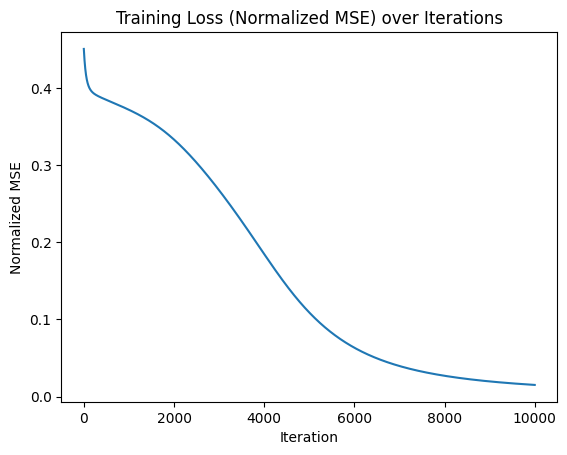

Inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Predictions: [0 0 0 1]
Actual AND: [0 0 0 1]


In [6]:
if __name__ == "__main__":
    # Layer sizes
    n_x, n_h, n_y = 2, 2, 1

    # Learning rate
    lr = 0.1
    # For reproducibility
    np.random.seed(42)

    # Initialize weights (small random values) and biases (zeros)
    W1 = np.random.randn(n_h, n_x) * 1              # shape (2,2)
    b1 = np.zeros((n_h, 1))                         # shape (2,1)
    W2 = np.random.randn(n_y, n_h) * 1              # shape (1,2)
    b2 = np.zeros((n_y, 1))                         # shape (1,1)

    # AND inputs
    a = np.array([0, 0, 1, 1])
    b = np.array([0, 1, 0, 1])

    # AND outputs (ground truth)
    Y = np.array([[0, 0, 0, 1]])

    # Stack inputs into a 2 x 4 matrix (each column is one example)
    X = np.vstack((a, b))

    # Number of examples
    m = X.shape[1]

    # Training loop
    X, W1, b1, W2, b2, loss_history = training_loop(X, Y, W1, b1, W2, b2, lr, m)

    plt.plot(loss_history)
    plt.title("Training Loss (Normalized MSE) over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Normalized MSE")
    plt.show()

    # Test on AND inputs
    preds = predict(X, W1, b1, W2, b2)
    print("Inputs:\n", X.T)
    print("Predictions:", preds.flatten())
    print("Actual AND:", Y.flatten())